<a href="https://colab.research.google.com/github/fatihpossumah/prediksi-stress-level/blob/main/Sleep_Mobile_Stress.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Prediksi Tingkat Stres Berbasis Machine Learning Menggunakan Data Perilaku Digital dan Pola Tidur**

## **Data Collection**

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('sleep_mobile_stress_dataset_15000.csv')

In [ ]:
df.head(10)

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99
5,6,56,Male,Teacher,7.26,10,7.79,6.16,10.00,2,50,198,7.85
6,7,36,Female,Teacher,4.56,83,6.81,6.81,5.38,0,19,39,5.52
7,8,40,Male,Manager,3.36,89,6.50,8.75,3.48,2,66,127,4.50
8,9,28,Male,Student,2.30,109,7.57,8.05,3.46,3,103,99,2.52
9,10,28,Female,Manager,9.75,46,4.73,5.52,10.00,3,56,121,10.00


In [ ]:
df = df.drop(columns=['user_id'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               15000 non-null  int64  
 1   gender                            15000 non-null  object 
 2   occupation                        15000 non-null  object 
 3   daily_screen_time_hours           15000 non-null  float64
 4   phone_usage_before_sleep_minutes  15000 non-null  int64  
 5   sleep_duration_hours              15000 non-null  float64
 6   sleep_quality_score               15000 non-null  float64
 7   stress_level                      15000 non-null  float64
 8   caffeine_intake_cups              15000 non-null  int64  
 9   physical_activity_minutes         15000 non-null  int64  
 10  notifications_received_per_day    15000 non-null  int64  
 11  mental_fatigue_score              15000 non-null  float64
dtypes: f

## **Data Preprocessing**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
occupation,0
daily_screen_time_hours,0
phone_usage_before_sleep_minutes,0
sleep_duration_hours,0
sleep_quality_score,0
stress_level,0
caffeine_intake_cups,0
physical_activity_minutes,0


In [ ]:
numerical_cols = [
    'age',
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    'sleep_duration_hours',
    'sleep_quality_score',
    'stress_level',
    'caffeine_intake_cups',
    'physical_activity_minutes',
    'notifications_received_per_day',
    'mental_fatigue_score'
]

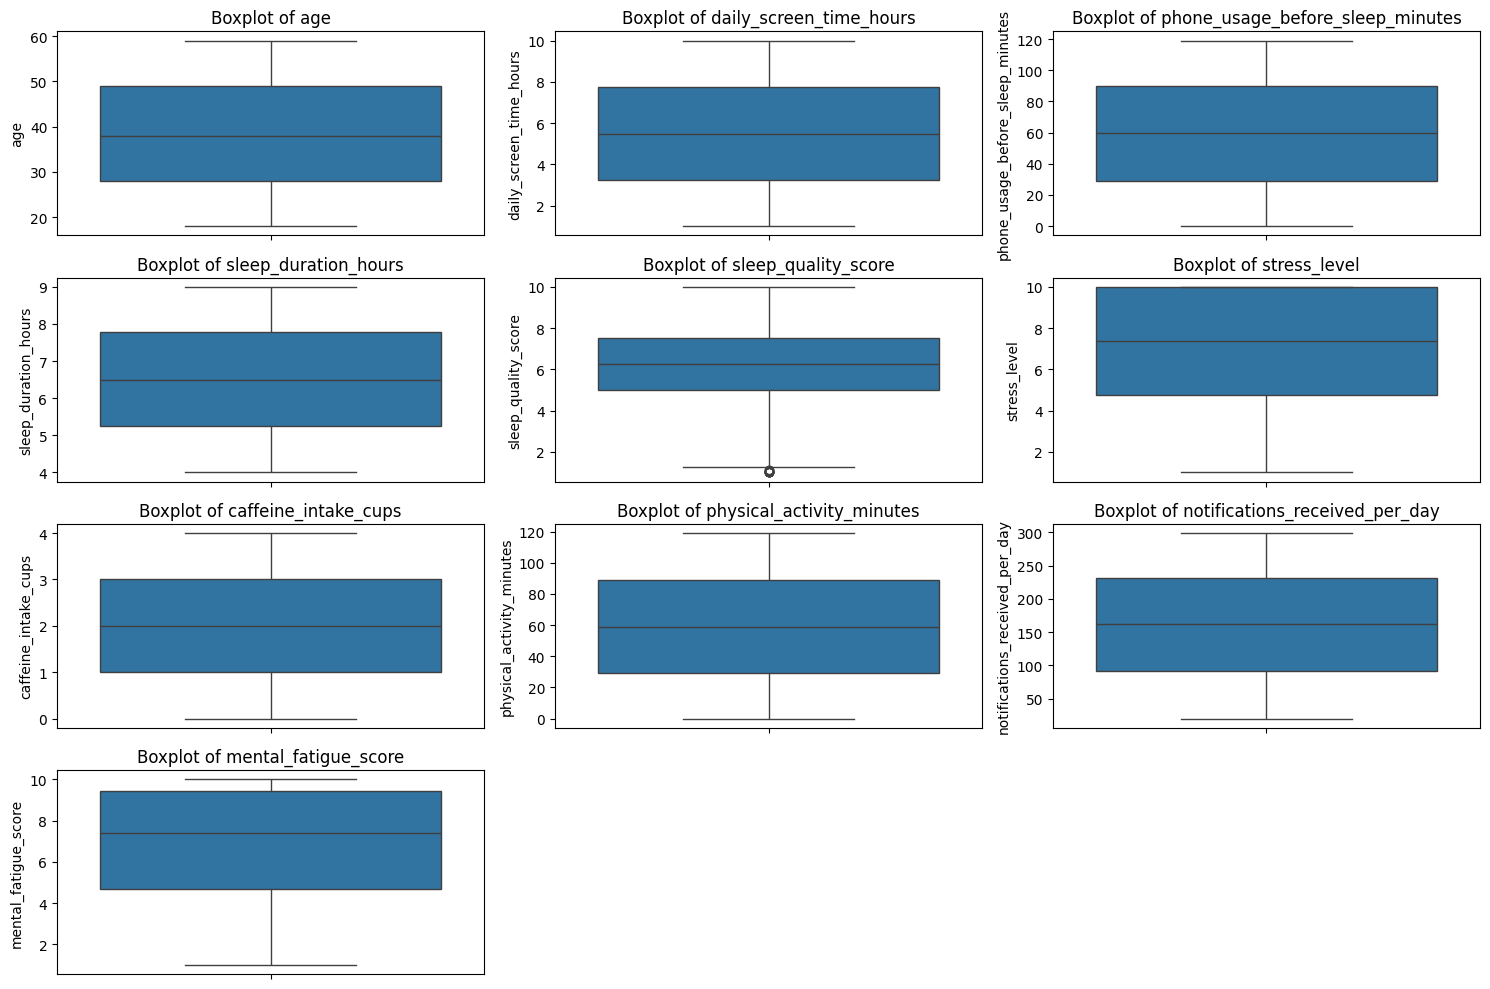

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [ ]:
df_cleaned = df.copy()

for col in numerical_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]

print(f"DataFrame shape before outlier removal: {df.shape}")
print(f"DataFrame shape after outlier removal: {df_cleaned.shape}")

DataFrame shape before outlier removal: (15000, 12)
DataFrame shape after outlier removal: (14991, 12)


In [ ]:
df_cleaned.head(10)

,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99
5,56,Male,Teacher,7.26,10,7.79,6.16,10.00,2,50,198,7.85
6,36,Female,Teacher,4.56,83,6.81,6.81,5.38,0,19,39,5.52
7,40,Male,Manager,3.36,89,6.50,8.75,3.48,2,66,127,4.50
8,28,Male,Student,2.30,109,7.57,8.05,3.46,3,103,99,2.52
9,28,Female,Manager,9.75,46,4.73,5.52,10.00,3,56,121,10.00


## **EDA**

In [ ]:
numerical_cols = [
    'age',
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    'sleep_duration_hours',
    'sleep_quality_score',
    'stress_level',
    'caffeine_intake_cups',
    'physical_activity_minutes',
    'notifications_received_per_day',
    'mental_fatigue_score'
]
categorical_cols = ['gender', 'occupation']

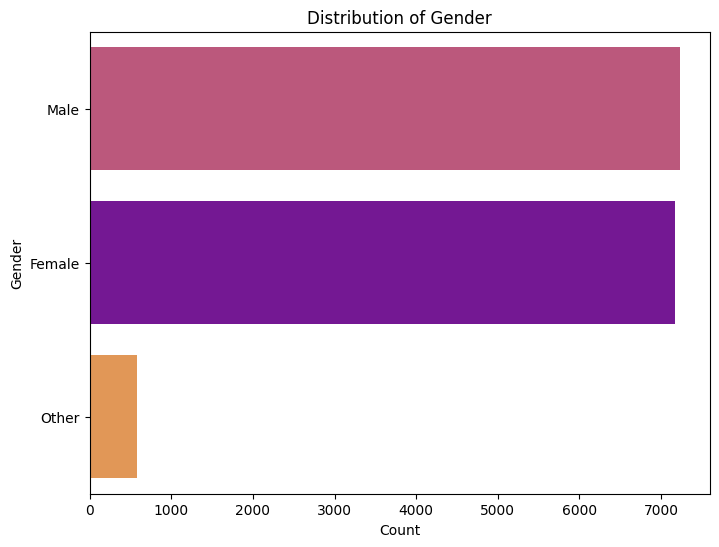

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(y='gender', hue='gender', data=df_cleaned, order=df_cleaned['gender'].value_counts().index ,palette='plasma', legend=False)
plt.title('Distribution of Gender')
plt.xlabel('Count')
plt.ylabel('Gender')
plt.show()

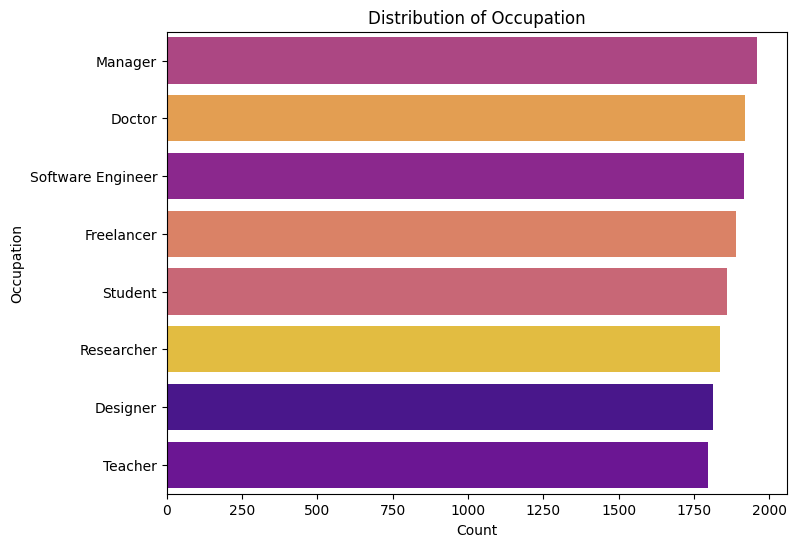

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(y='occupation', hue='occupation', data=df_cleaned, order=df_cleaned['occupation'].value_counts().index ,palette='plasma', legend=False)
plt.title('Distribution of Occupation')
plt.xlabel('Count')
plt.ylabel('Occupation')
plt.show()

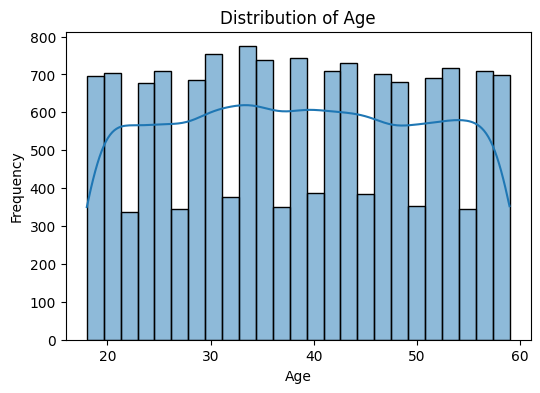

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df_cleaned['age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

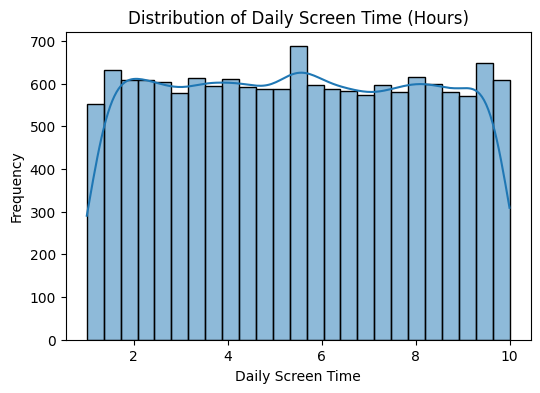

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df_cleaned['daily_screen_time_hours'], kde=True)
plt.title('Distribution of Daily Screen Time (Hours)')
plt.xlabel('Daily Screen Time')
plt.ylabel('Frequency')
plt.show()

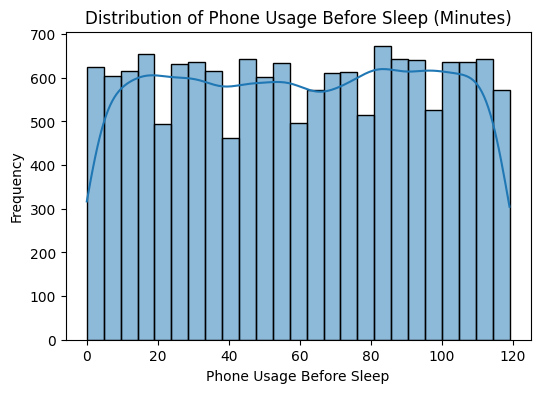

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df_cleaned['phone_usage_before_sleep_minutes'], kde=True)
plt.title('Distribution of Phone Usage Before Sleep (Minutes)')
plt.xlabel('Phone Usage Before Sleep')
plt.ylabel('Frequency')
plt.show()

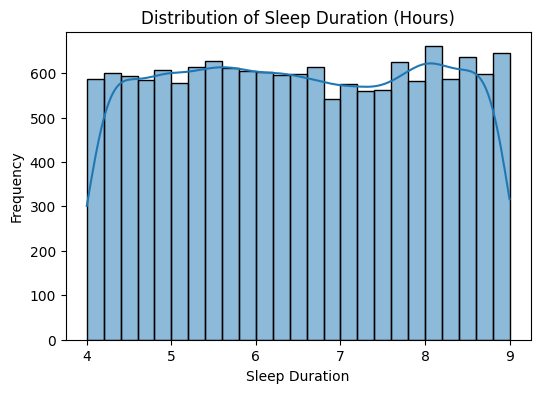

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df_cleaned['sleep_duration_hours'], kde=True)
plt.title('Distribution of Sleep Duration (Hours)')
plt.xlabel('Sleep Duration')
plt.ylabel('Frequency')
plt.show()

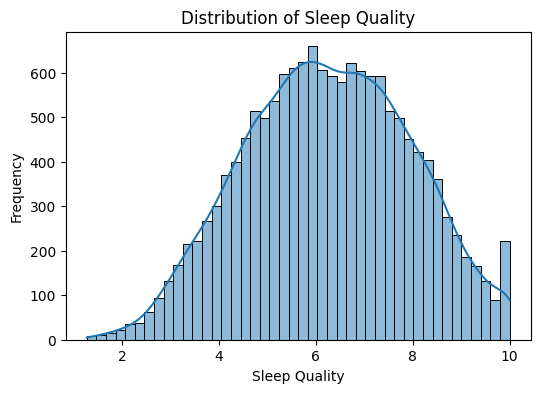

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df_cleaned['sleep_quality_score'], kde=True)
plt.title('Distribution of Sleep Quality')
plt.xlabel('Sleep Quality')
plt.ylabel('Frequency')
plt.show()

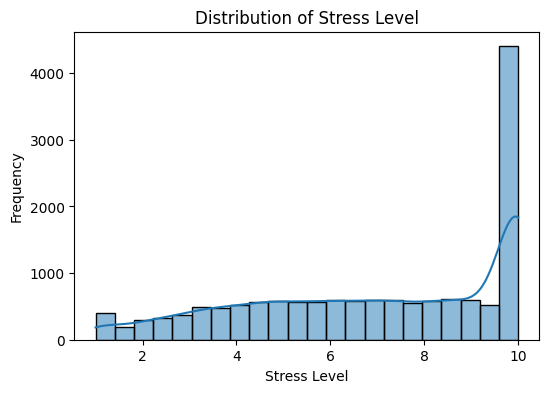

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df_cleaned['stress_level'], kde=True)
plt.title('Distribution of Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Frequency')
plt.show()

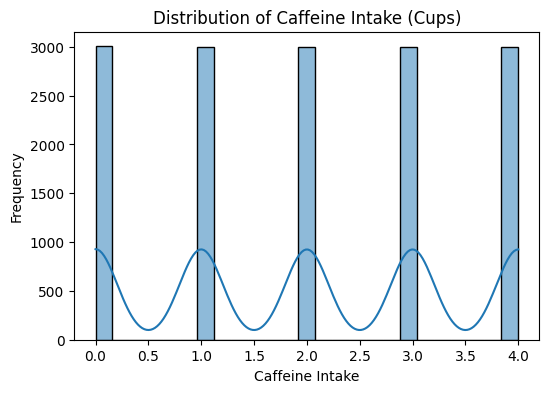

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df_cleaned['caffeine_intake_cups'], kde=True)
plt.title('Distribution of Caffeine Intake (Cups)')
plt.xlabel('Caffeine Intake')
plt.ylabel('Frequency')
plt.show()

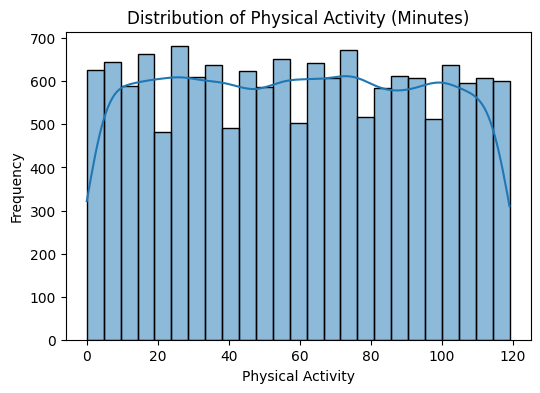

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df_cleaned['physical_activity_minutes'], kde=True)
plt.title('Distribution of Physical Activity (Minutes)')
plt.xlabel('Physical Activity')
plt.ylabel('Frequency')
plt.show()

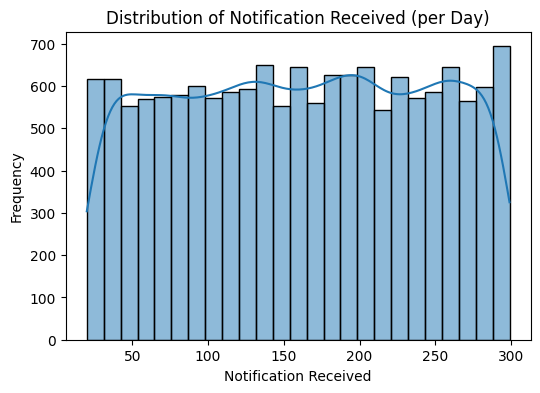

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df_cleaned['notifications_received_per_day'], kde=True)
plt.title('Distribution of Notification Received (per Day)')
plt.xlabel('Notification Received')
plt.ylabel('Frequency')
plt.show()

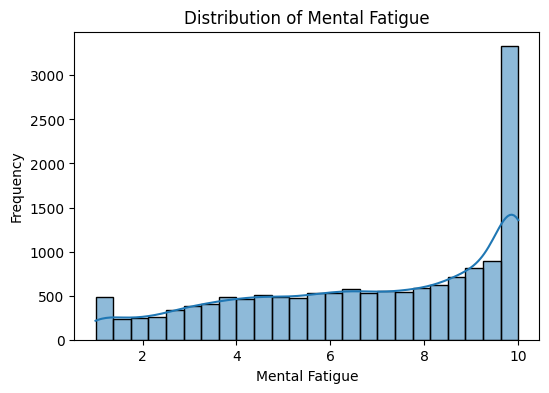

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df_cleaned['mental_fatigue_score'], kde=True)
plt.title('Distribution of Mental Fatigue')
plt.xlabel('Mental Fatigue')
plt.ylabel('Frequency')
plt.show()

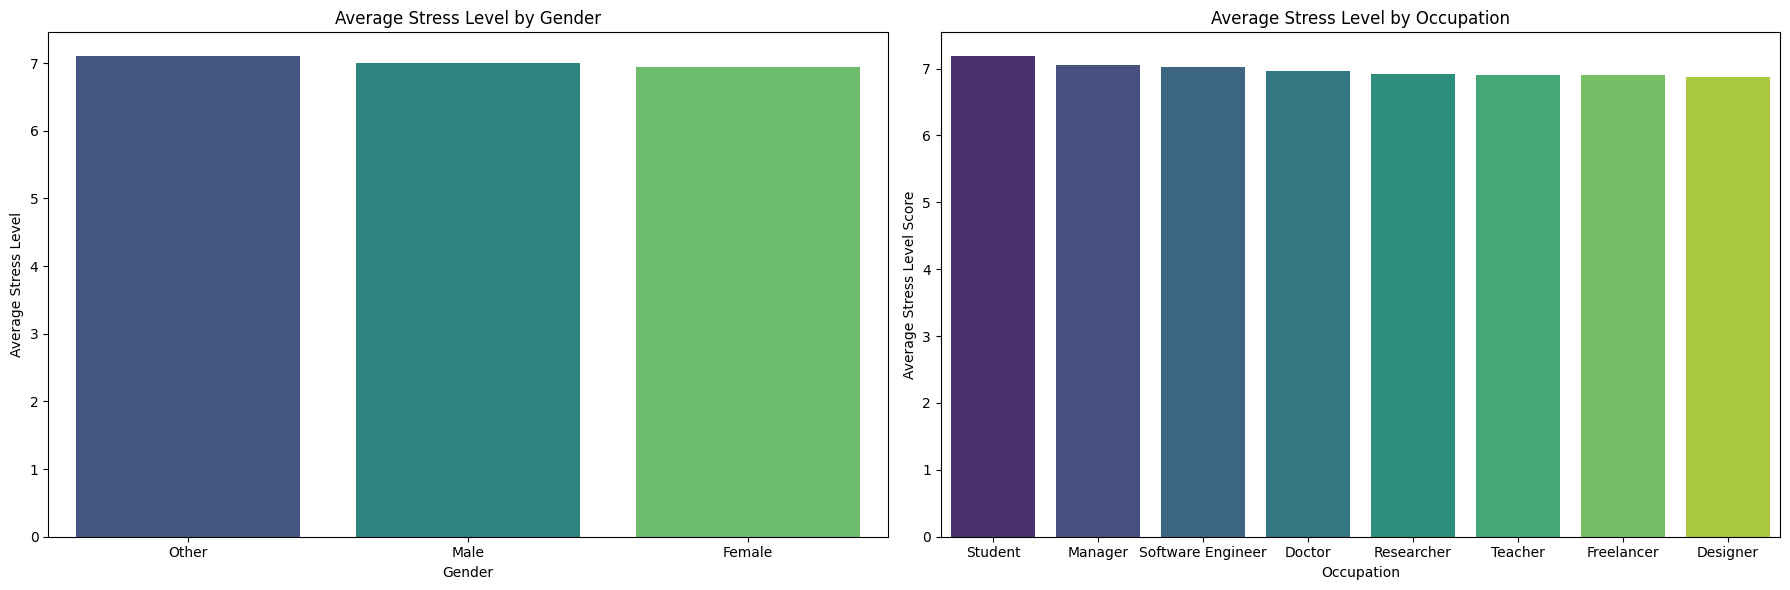

In [ ]:
plt.figure(figsize=(18, 6))

avg_price_cut = df_cleaned.groupby('gender')['stress_level'].mean().sort_values(ascending=False).reset_index()
plt.subplot(1, 2, 1)
sns.barplot(x='gender', y='stress_level', hue='gender', data=avg_price_cut, palette='viridis', legend=False)
plt.title('Average Stress Level by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Stress Level')

avg_price_color = df_cleaned.groupby('occupation')['stress_level'].mean().sort_values(ascending=False).reset_index()
plt.subplot(1, 2, 2)
sns.barplot(x='occupation', y='stress_level', hue='occupation', data=avg_price_color, palette='viridis', legend=False)
plt.title('Average Stress Level by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Average Stress Level Score')

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

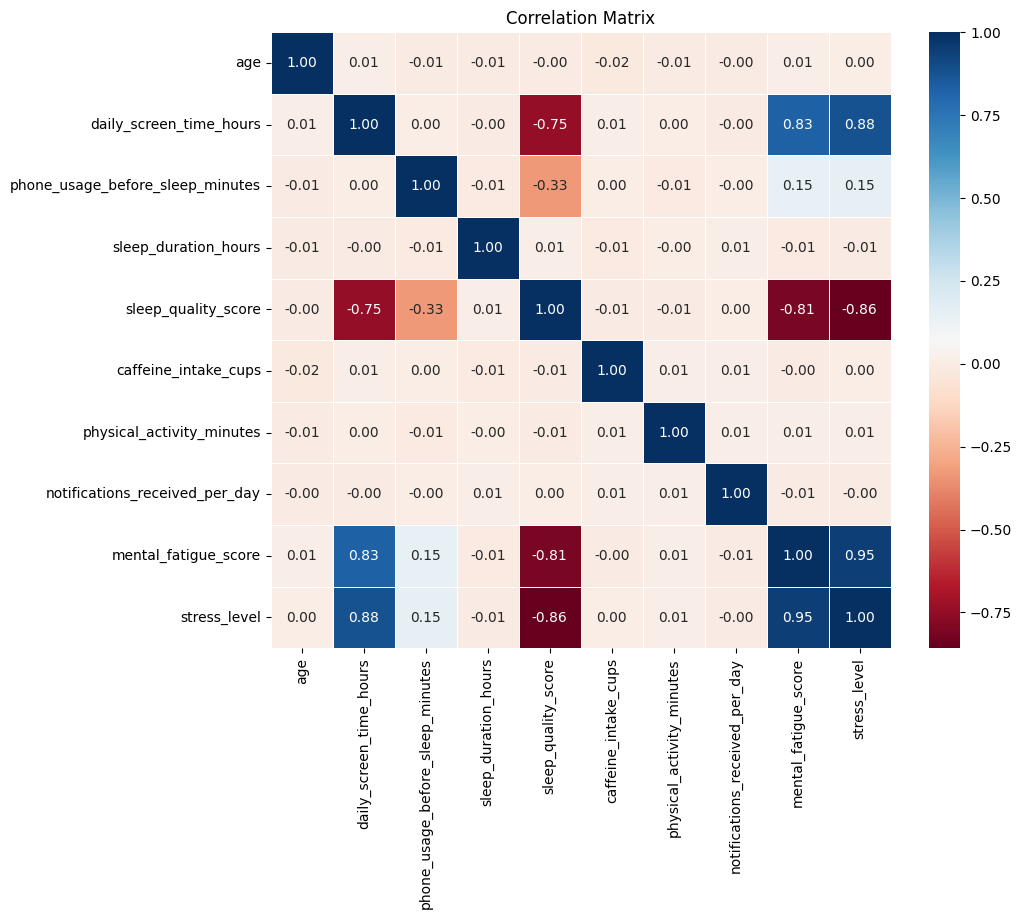

In [ ]:
numerical_cols = [c for c in df_cleaned.select_dtypes(include=['float64', 'int64']).columns if c != 'stress_level']

numerical_cols.append('stress_level')

corr_matrix = df_cleaned[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdBu',
    fmt='.2f',
    linewidths=0.5,
)
plt.title('Correlation Matrix')
plt.savefig('correlation_matrix.png')
plt.show

In [ ]:
corr_target = corr_matrix['stress_level'].drop('stress_level')

threshold = 0.05

low_corr_features = corr_target[abs(corr_target) < threshold].index.tolist()

print("Fitur dengan korelasi rendah:", low_corr_features)

df_reduced = df_cleaned.drop(columns=low_corr_features)

print("Shape sebelum:", df_cleaned.shape)
print("Shape sesudah:", df_reduced.shape)

Fitur dengan korelasi rendah: ['age', 'sleep_duration_hours', 'caffeine_intake_cups', 'physical_activity_minutes', 'notifications_received_per_day']
Shape sebelum: (14991, 12)
Shape sesudah: (14991, 7)


## **Feature Engineering**

In [ ]:
gender_categories = sorted(df_reduced['gender'].unique().tolist())
occupation_categories = sorted(df_reduced['occupation'].unique().tolist())

In [ ]:
import pickle, json

category_info = {
    'gender': gender_categories,
    'occupation': occupation_categories
}

with open('category_info.json', 'w') as f:
    json.dump(category_info, f)
print("Category info saved:", category_info)

Category info saved: {'gender': ['Female', 'Male', 'Other'], 'occupation': ['Designer', 'Doctor', 'Freelancer', 'Manager', 'Researcher', 'Software Engineer', 'Student', 'Teacher']}


In [ ]:
df_encoded = pd.get_dummies(df_reduced, columns=['gender','occupation'])

In [ ]:
X = df_encoded.drop('stress_level', axis=1)
y = df_encoded['stress_level']

In [ ]:
feature_columns = X.columns.tolist()
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)
print(f"Total features: {len(feature_columns)}")
print("Feature columns saved.")

Total features: 15
Feature columns saved.


In [ ]:
print(df_encoded.head())

   daily_screen_time_hours  phone_usage_before_sleep_minutes  \
0                     3.26                                86   
1                     1.85                                32   
2                     3.04                               107   
3                     9.00                                36   
4                     3.52                                56   

   sleep_quality_score  stress_level  mental_fatigue_score  gender_Female  \
0                 7.72          3.49                  3.57           True   
1                 9.70          3.01                  1.91           True   
2                 6.38          5.03                  6.05           True   
3                 5.53         10.00                  9.92          False   
4                 6.69          6.71                  5.99           True   

   gender_Male  gender_Other  occupation_Designer  occupation_Doctor  \
0        False         False                 True              False   
1       

In [ ]:
from sklearn.preprocessing import StandardScaler

scale_cols = [
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    'sleep_quality_score',
    'mental_fatigue_score'
]

In [ ]:
from sklearn.model_selection import train_test_split

X_train_for_scaler, _, y_train_for_scaler, _ = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
scaler.fit(X_train_for_scaler[scale_cols])

X[scale_cols] = scaler.transform(X[scale_cols])

pickle.dump(scaler, open("scaler.pkl", "wb"))
print("Scaler saved.")

Scaler saved.


In [ ]:
print(X.head())
print(X.columns)

   daily_screen_time_hours  phone_usage_before_sleep_minutes  \
0                -0.860819                          0.764605   
1                -1.404073                         -0.796154   
2                -0.945582                          1.371566   
3                 1.350728                         -0.680542   
4                -0.760644                         -0.102483   

   sleep_quality_score  mental_fatigue_score  gender_Female  gender_Male  \
0             0.862598             -1.207498           True        False   
1             2.025730             -1.814976           True        False   
2             0.075427             -0.299942           True        False   
3            -0.423897              1.116285          False         True   
4             0.257534             -0.321899           True        False   

   gender_Other  occupation_Designer  occupation_Doctor  \
0         False                 True              False   
1         False                False    

## **Model Selection & Training**

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
test_sizes = [0.2, 0.3, 0.4, 0.1]  # 80:20, 70:30, 60:40, 90:10
split_names = ['82', '73', '64', '91']

all_results = {}

print("\n" + "="*50)
print("TUNING PARAMETER 80:20")
print("="*50)

X_train_tune, X_test_tune, y_train_tune, y_test_tune = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train shape for tuning:", X_train_tune.shape)
print("Test shape for tuning :", X_test_tune.shape)


TUNING PARAMETER 80:20
Train shape for tuning: (11992, 15)
Test shape for tuning : (2999, 15)


In [ ]:
print("RANDOM FOREST TUNING")
print("="*50)
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=42)
rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train_tune, y_train_tune)

rf_best_params = rf_grid.best_params_
print(f"Best Parameters RF: {rf_best_params}")

RANDOM FOREST TUNING
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters RF: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
print("KNN TUNING")
print("="*50)
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsRegressor()
knn_grid = GridSearchCV(
    knn,
    knn_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
knn_grid.fit(X_train_tune, y_train_tune)

knn_best_params = knn_grid.best_params_
print(f"Best Parameters KNN: {knn_best_params}")

KNN TUNING
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters KNN: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}


In [ ]:
print("XGBOOST TUNING")
print("="*50)
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

xgb = XGBRegressor(random_state=42)
xgb_grid = GridSearchCV(
    xgb,
    xgb_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train_tune, y_train_tune)

xgb_best_params = xgb_grid.best_params_
print(f"Best Parameters XGB: {xgb_best_params}")

XGBOOST TUNING
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters XGB: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


## **Model Evaluation**

In [ ]:
print("EVALUASI UNTUK SEMUA RASIO SPLIT")
print("="*50)

for test_size, split_name in zip(test_sizes, split_names):
    print(f"\n{'-'*40}")
    print(f"RASIO {split_name} (test_size={test_size})")
    print(f"{'-'*40}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42)

    print("Train shape:", X_train.shape)
    print("Test shape :", X_test.shape)

    results = {}

    rf_model = RandomForestRegressor(**rf_best_params, random_state=42)
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)

    results['Random Forest'] = {
        'MAE': mean_absolute_error(y_test, y_pred_rf),
        'MSE': mean_squared_error(y_test, y_pred_rf),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        'R2': r2_score(y_test, y_pred_rf)
    }

    knn_model = KNeighborsRegressor(**knn_best_params)
    knn_model.fit(X_train, y_train)
    y_pred_knn = knn_model.predict(X_test)

    results['KNN'] = {
        'MAE': mean_absolute_error(y_test, y_pred_knn),
        'MSE': mean_squared_error(y_test, y_pred_knn),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_knn)),
        'R2': r2_score(y_test, y_pred_knn)
    }

    xgb_model = XGBRegressor(**xgb_best_params, random_state=42)
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)

    results['XGBoost'] = {
        'MAE': mean_absolute_error(y_test, y_pred_xgb),
        'MSE': mean_squared_error(y_test, y_pred_xgb),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        'R2': r2_score(y_test, y_pred_xgb)
    }

    all_results[f'rasio_{split_name}'] = results

EVALUASI UNTUK SEMUA RASIO SPLIT

----------------------------------------
RASIO 82 (test_size=0.2)
----------------------------------------
Train shape: (11992, 15)
Test shape : (2999, 15)

----------------------------------------
RASIO 73 (test_size=0.3)
----------------------------------------
Train shape: (10493, 15)
Test shape : (4498, 15)

----------------------------------------
RASIO 64 (test_size=0.4)
----------------------------------------
Train shape: (8994, 15)
Test shape : (5997, 15)

----------------------------------------
RASIO 91 (test_size=0.1)
----------------------------------------
Train shape: (13491, 15)
Test shape : (1500, 15)


In [ ]:
print("RINGKASAN HASIL SEMUA RASIO")
print("="*50)

for rasio, results in all_results.items():
    print(f"\n{rasio.upper()}:")
    print("-" * 40)

    df_temp = pd.DataFrame({
        'Model': list(results.keys()),
        'MAE': [results[m]['MAE'] for m in results.keys()],
        'MSE': [results[m]['MSE'] for m in results.keys()],
        'RMSE': [results[m]['RMSE'] for m in results.keys()],
        'R2': [results[m]['R2'] for m in results.keys()]
    })

    print(df_temp.to_string(index=False))

    best_model = max(results.keys(), key=lambda x: results[x]['R2'])
    print(f"\nModel terbaik untuk {rasio}: {best_model} (R2={results[best_model]['R2']:.4f})")

RINGKASAN HASIL SEMUA RASIO

RASIO_82:
----------------------------------------
        Model      MAE      MSE     RMSE       R2
Random Forest 0.427812 0.354624 0.595503 0.952970
          KNN 0.455145 0.397019 0.630094 0.947348
      XGBoost 0.426268 0.345691 0.587955 0.954155

Model terbaik untuk rasio_82: XGBoost (R2=0.9542)

RASIO_73:
----------------------------------------
        Model      MAE      MSE     RMSE       R2
Random Forest 0.442859 0.378463 0.615194 0.950152
          KNN 0.468064 0.416882 0.645664 0.945092
      XGBoost 0.444058 0.369146 0.607574 0.951379

Model terbaik untuk rasio_73: XGBoost (R2=0.9514)

RASIO_64:
----------------------------------------
        Model      MAE      MSE     RMSE       R2
Random Forest 0.444750 0.377181 0.614151 0.950861
          KNN 0.473640 0.423930 0.651099 0.944770
      XGBoost 0.444589 0.366863 0.605692 0.952205

Model terbaik untuk rasio_64: XGBoost (R2=0.9522)

RASIO_91:
----------------------------------------
        Mod

In [ ]:
print("Model terbaik: XGBoost dengan parameter:", xgb_best_params)

final_model = XGBRegressor(**xgb_best_params, random_state=42)
final_model.fit(X, y)

Model terbaik: XGBoost dengan parameter: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
import joblib
joblib.dump(final_model, 'final_model_xgb.pkl')
print("Model final siap deploy!")

Model final siap deploy!


In [ ]:
import pickle, json
import pandas as pd

def preprocess_input(input_dict) -> pd.DataFrame:

  with open('feature_columns.pkl', 'rb') as f:
    feature_columns = pickle.load(f)

  scaler = pickle.load(open('scaler.pkl', 'rb'))

  with open('category_info.json', 'r') as f:
    category_info = json.load(f)

  input_df = pd.DataFrame([input_dict])

  for col, categories in category_info.items():
    for cat in categories:
      col_name = f"{col}_{cat}"
      input_df[col_name] = (input_df[col] == cat).astype(int)
    input_df.drop(columns=[col], inplace=True)

  input_df = input_df.reindex(columns=feature_columns, fill_value=0)

  scale_cols = [
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    'sleep_quality_score',
    'mental_fatigue_score'
]
  input_df[scale_cols] = scaler.transform(input_df[scale_cols])

  return input_df

In [ ]:
def predict_stress(input_data):
    model = joblib.load('final_model_xgb.pkl')

    processed_df = preprocess_input(input_data)

    prediction = model.predict(processed_df)[0]

    return round(float(prediction), 2)

sample_user = {
    'gender': 'Male',
    'occupation': 'Student',
    'daily_screen_time_hours': 6,
    'phone_usage_before_sleep_minutes': 30,
    'sleep_quality_score': 5.0,
    'mental_fatigue_score': 5.0
}

result = predict_stress(sample_user)
print(f"Prediksi Tingkat Stres: {result}")

Prediksi Tingkat Stres: 7.0
